**Scenario 1: E-commerce Sales Data**

This scenario focuses on handling high-cardinality categorical data (like product descriptions) and time-series trends.

STUDENT NAME: SHAILESH GOWTHAM
R.NO: 24BAD108

--- Head ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Co

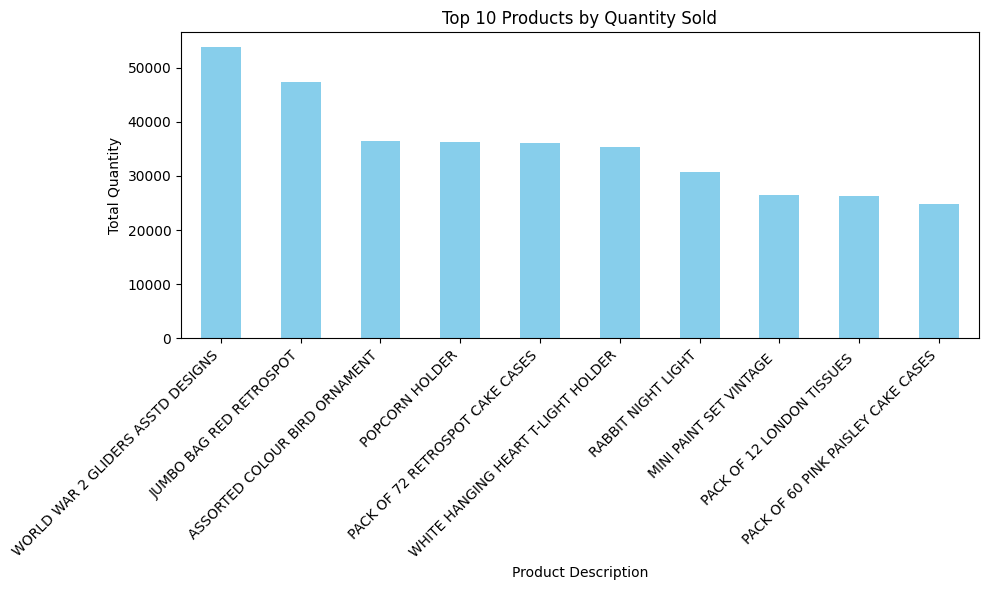

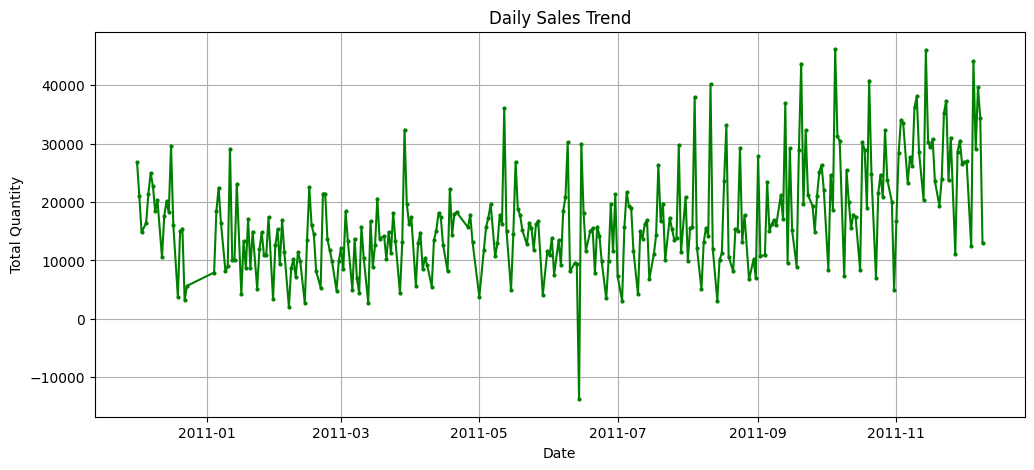

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identification
print("STUDENT NAME: SHAILESH GOWTHAM")
print("R.NO: 24BAD108\n")

# 1. Load the dataset
# Note: This dataset often requires ISO-8859-1 encoding
df = pd.read_csv("G:\\Study materials\\ML\\Datasets\\data.csv", encoding='ISO-8859-1')

# 2. Inspect the dataset
print("--- Head ---")
print(df.head())
print("\n--- Info ---")
df.info()
print("\n--- Describe ---")
print(df.describe())

# 3. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 4. Visualize sales per product (Top 10)
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Visualize sales trend (Line Chart)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['Quantity'].sum()

plt.figure(figsize=(12, 5))
daily_sales.plot(kind='line', marker='o', markersize=2, color='green')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Quantity')
plt.grid(True)
plt.show()

**Scenario 2: Hospital Patient Records (Pima Diabetes)**

This dataset is famous for "hidden" missing values (where 0 is used for metrics like Blood Pressure or Glucose that shouldn't be zero).

STUDENT NAME: SHAILESH GOWTHAM
R.NO: 24BAD108

Dataset Shape: (768, 9)

Missing Values Count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


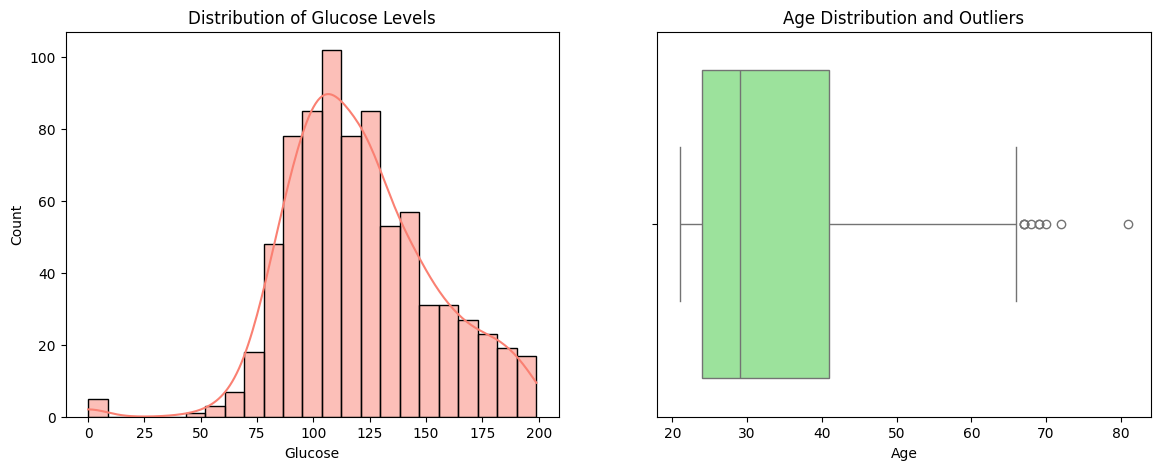


Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("STUDENT NAME: SHAILESH GOWTHAM")
print("R.NO: 24BAD108\n")

# 1. Load dataset
df = pd.read_csv("G:\\Study materials\\ML\\Datasets\\diabetes.csv")

# 2. Explore structure
print("Dataset Shape:", df.shape)
print("\nMissing Values Count:")
print(df.isnull().sum())

# 3. Visualize Glucose and Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for Glucose
sns.histplot(df['Glucose'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Glucose Levels')

# Boxplot for Age
sns.boxplot(x=df['Age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Age Distribution and Outliers')

plt.show()

# 4. Pattern identification (Correlation)
print("\nCorrelation with Outcome:")
print(df.corr()['Outcome'].sort_values(ascending=False))

**Scenario 3: Housing Dataset**

Here, you are looking for the "drivers" of price. Visualizing correlations is key to feature selection.

STUDENT NAME: SHAILESH GOWTHAM
R.NO: 24BAD108

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values Summary:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


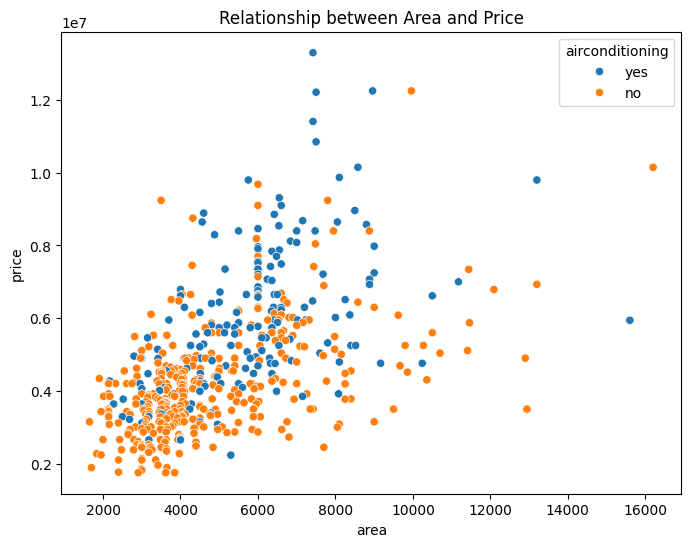

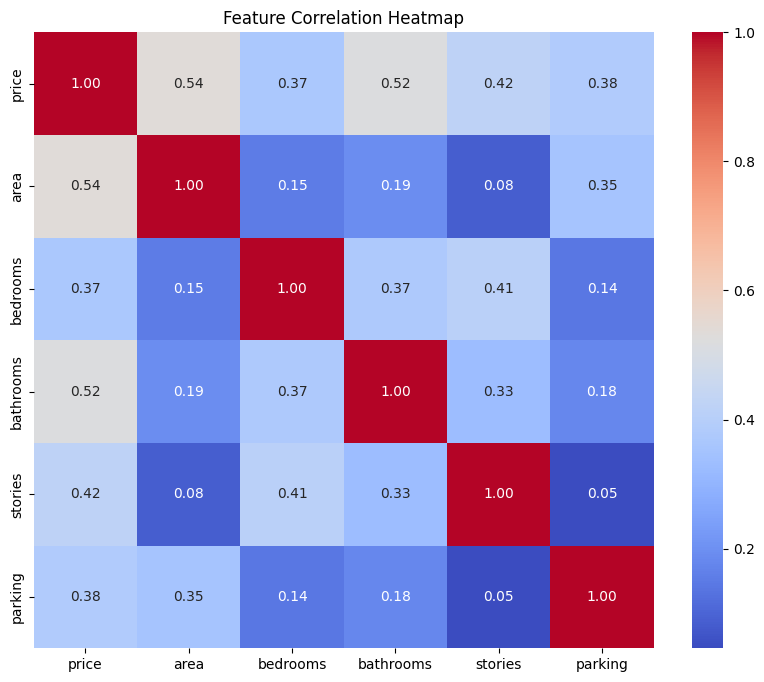

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("STUDENT NAME: SHAILESH GOWTHAM")
print("R.NO: 24BAD108\n")

# 1. Load and Inspect
df = pd.read_csv("G:\\Study materials\\ML\\Datasets\\housing.csv")
print("Columns:", df.columns.tolist())

# 2. Detect missing values
print("\nMissing Values Summary:")
print(df.isnull().sum())

# 3. Scatter plot: Area vs Price
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='area', y='price', hue='airconditioning')
plt.title('Relationship between Area and Price')
plt.show()

# 4. Heatmap of correlations
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

**Scenario 4: Banking Customer Data**

This scenario involves "Feature Engineering" (like calculating Age from Year_Birth) and analyzing spending behavior.

STUDENT NAME: SHAILESH GOWTHAM
R.NO: 24BAD108

Column Types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Null Values:
ID          

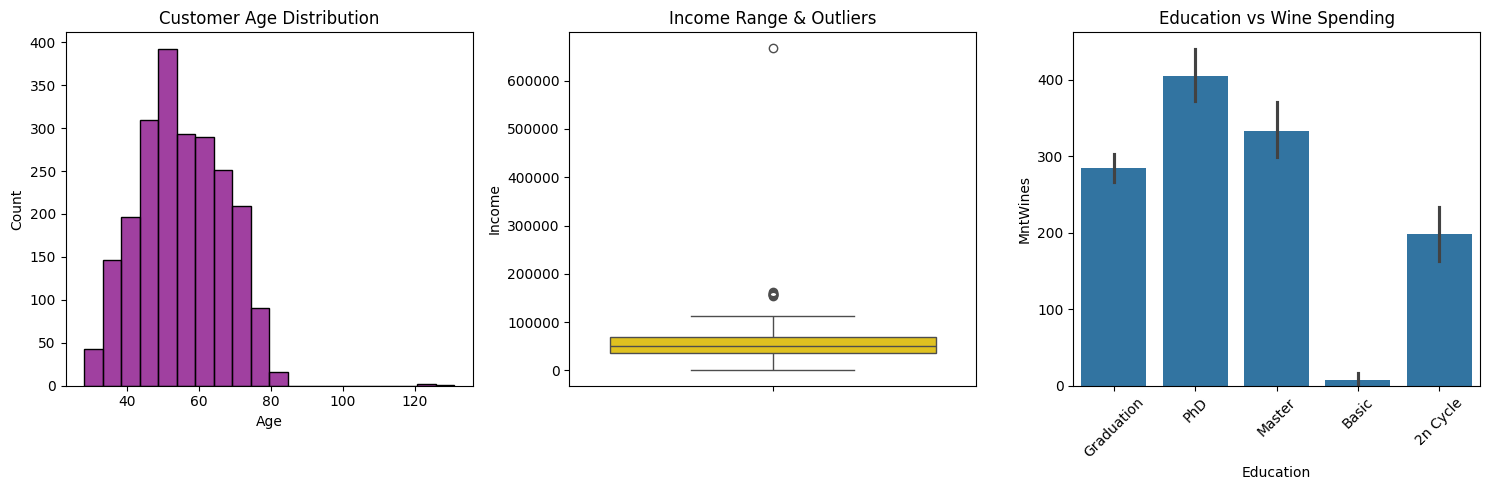


--- Insights Summary ---
Mean Income: 52247.25
Total missing in Income: 24


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("STUDENT NAME: SHAILESH GOWTHAM")
print("R.NO: 24BAD108\n")

# 1. Import and Examine
# This dataset often uses tab separation
df = pd.read_csv("G:\\Study materials\\ML\\Datasets\\marketing_campaign.csv", sep='\t')

print("Column Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())

# 2. Basic Feature Engineering for visualization
df['Age'] = 2024 - df['Year_Birth']

# 3. Visualizations
plt.figure(figsize=(15, 5))

# Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=20, color='purple')
plt.title('Customer Age Distribution')

# Income Distribution (Boxplot to see outliers)
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Income'], color='gold')
plt.title('Income Range & Outliers')

# Spending Pattern: Education vs Income
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='Education', y='MntWines')
plt.title('Education vs Wine Spending')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n--- Insights Summary ---")
print(f"Mean Income: {df['Income'].mean():.2f}")
print(f"Total missing in Income: {df['Income'].isnull().sum()}")